# The LLAMA of WallStreet

Obiettivo:
- estrazione ticker con LLM
- sentiment analysis
- aggregazione giornaliera
- trend analysis

Dataset:
- 101.974 commenti Reddit


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!cp '/content/drive/MyDrive/reddit_comments.csv' 'reddit_comments.csv'

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import pipeline
from openai import OpenAI

df = pd.read_csv("reddit_comments.csv")

print(df.shape)

df.head()

(101974, 4)


,datetime,subreddits,submission_id,comments
0,2025-03-29 18:32:13,news,1jmrj8p,A British man has been praised for tackling a ...
1,2025-03-29 18:32:13,news,1jmrj8p,Glad they recognized him. He did a great thing.
2,2025-03-29 18:32:13,news,1jmrj8p,A news on a British tourist that doesn't invol...
3,2025-03-29 18:32:13,news,1jmrj8p,That guys needs some real love. Hopefully he A...
4,2025-03-29 18:32:13,news,1jmrj8p,"“I’m Millwall, mate”. Probably"


In [6]:
df.info()

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101974 entries, 0 to 101973
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   datetime       101974 non-null  object
 1   subreddits     101974 non-null  object
 2   submission_id  101974 non-null  object
 3   comments       101974 non-null  object
dtypes: object(4)
memory usage: 3.1+ MB


,0
datetime,0
subreddits,0
submission_id,0
comments,0


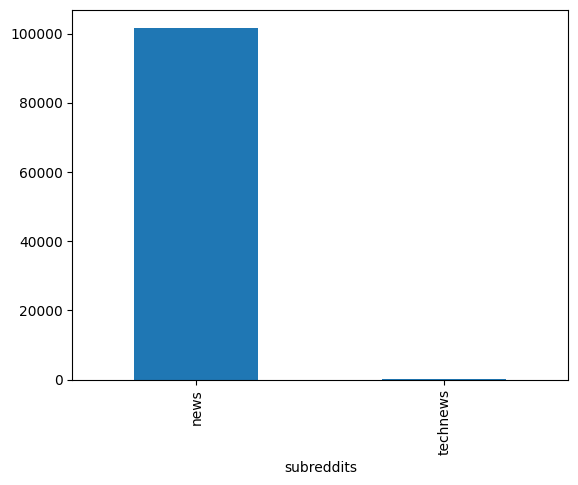

In [7]:
#EDA
df["subreddits"].value_counts()
df["comments"].str.len().describe()
df["subreddits"].value_counts().plot.bar()
plt.show()

## Ticker extraction using Mistral 24B

We use an LLM to identify listed companies
and map them to stock tickers.

In [8]:
# Basic company dictionary for filtering
COMPANY_TO_TICKER = {
    "apple": "AAPL",
    "tesla": "TSLA",
    "amazon": "AMZN",
    "google": "GOOGL",
    "alphabet": "GOOGL",
    "meta": "META",
    "facebook": "META",
    "microsoft": "MSFT",
    "nvidia": "NVDA",
    "boeing": "BA",
    "intel": "INTC",
    "amd": "AMD",
    "netflix": "NFLX"
}

In [9]:
# Remove irrelevant comments + extract tickers
def extract_tickers_rule_based(comment):
    text = str(comment).lower()
    tickers = []

    for company, ticker in COMPANY_TO_TICKER.items():
        if company in text:
            tickers.append(ticker)

    return list(set(tickers))

## Sentiment extraction

Model:
cardiffnlp/twitter-roberta-base-sentiment-latest

In [10]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [12]:
def classify_sentiment(comment):
    result = sentiment_model(str(comment)[:512])[0]
    label = result["label"].lower()
    confidence = result["score"]

    if label == "positive":
        return ("Very Positive", 2) if confidence > 0.9 else ("Positive", 1)

    if label == "negative":
        return ("Very Negative", -2) if confidence > 0.9 else ("Negative", -1)

    return "Neutral", 0

In [13]:
# full pipeline on sample
sample_df = df.head(5000)

results = []

for _, row in sample_df.iterrows():
    comment = row["comments"]

    tickers = extract_tickers_rule_based(comment)

    if len(tickers) == 0:
        continue

    sentiment, score = classify_sentiment(comment)

    for ticker in tickers:
        results.append({
            "datetime": row["datetime"],
            "ticker": ticker,
            "comment": comment,
            "sentiment": sentiment,
            "score": score
        })

processed_df = pd.DataFrame(results)

processed_df["datetime"] = pd.to_datetime(processed_df["datetime"])
processed_df["date"] = processed_df["datetime"].dt.date

processed_df.head()

,datetime,ticker,comment,sentiment,score,date
0,2024-12-29 22:12:57,AAPL,Too good to be POTUS. This quote from the WaPo...,Positive,1,2024-12-29
1,2024-05-30 23:09:25,AMD,Trump’s guilty of 34 felony counts so far…\nAn...,Very Negative,-2,2024-05-30
2,2024-11-14 15:09:46,META,The Onion gets meta. A sign of the times.,Neutral,0,2024-11-14
3,2024-08-06 15:04:23,INTC,"Having known next to nothing about him, watchi...",Very Positive,2,2024-08-06
4,2024-12-10 22:04:52,GOOGL,You'll forgive me if my sympathy coverage ran ...,Negative,-1,2024-12-10


Very Positive -> 2
Positive -> 1
Neutral -> 0
Negative -> -1
Very Negative -> -2

In [14]:
# daily aggregation
daily_stats = (
    processed_df
    .groupby(["date", "ticker"])
    .agg(
        avg_sentiment=("score", "mean"),
        min_sentiment=("score", "min"),
        max_sentiment=("score", "max"),
        comment_count=("score", "count")
    )
    .reset_index()
)

daily_stats.head()

,date,ticker,avg_sentiment,min_sentiment,max_sentiment,comment_count
0,2024-03-11,BA,-0.865385,-2,1,52
1,2024-03-11,NFLX,2.000000,2,2,1
2,2024-03-15,AMZN,-1.000000,-1,-1,3
3,2024-03-15,BA,-1.000000,-2,0,19
4,2024-05-30,AMD,-2.000000,-2,-2,1


## Limitations

### Sarcasm and Irony
- Example: *"Great job Boeing, another plane fell apart."*
- The sentiment model may incorrectly classify sarcastic comments as positive because of the wording.

### Multiple Companies in the Same Comment
- Example: *"AMD is outperforming Intel."*
- A single comment may mention multiple companies with different sentiments, making sentiment assignment more challenging.

### Company Aliases and Ambiguous Names
- Some companies can be referred to using different names:
  - Meta / Facebook
  - Google / Alphabet
- Certain names may also have non-company meanings (e.g., Apple).

### Noisy Reddit Discussions
- Reddit comments often contain:
  - Memes
  - Jokes
  - Political discussions
  - Off-topic content
- These elements can reduce sentiment analysis accuracy.

### Domain Mismatch
- The sentiment model was trained on general social media data.
- Financial language may contain specific terminology not fully captured by the model.

---

## Future Improvements

### FinBERT Integration
- Use a finance-specific sentiment model such as FinBERT.
- Better understanding of financial terminology and market-related discussions.

### Larger Financial Datasets
- Include additional financial communities such as:
  - r/stocks
  - r/investing
  - r/wallstreetbets

### Retrieval-Augmented Ticker Extraction
- Validate extracted company names against a stock market database.
- Reduce ticker assignment errors and ambiguities.

### Real Stock Price Correlation
- Compare sentiment trends with actual stock price movements.
- Evaluate whether Reddit sentiment has predictive power.

### Entity-Level Sentiment Analysis
- Assign sentiment separately to each company mentioned in a comment.
- Improve handling of comments discussing multiple companies.

### Automated Nightly Execution on Leonardo
- Integrate the pipeline with a SLURM-based agent.
- Automatically run sentiment analysis every night and generate updated reports.

---

## Conclusion

Our goal was not to build a perfect trading system, but to demonstrate a scalable pipeline combining LLM-based information extraction, sentiment analysis, and large-scale processing on an HPC infrastructure.

The proposed solution successfully extracts stock-related information from Reddit comments, assigns sentiment scores, and aggregates results into meaningful daily indicators that can support further financial analysis.